# 02: Network Depth Experiments

## Overview & Objective
Having verified our data pipeline and established a baseline benchmark with a 2-hidden-layer MLP, this notebook explores how network depth impacts model capacity and feature resolution for EEG seizure classification. 

Specifically, we evaluate performance across three depth configurations:
* **1 Hidden Layer `[128]`:** Minimal non-linear capacity control.
* **2 Hidden Layers `[128, 64]` (Baseline):** Verified reference model (78.92% Test Accuracy / 0.7747 Macro F1).
* **3 Hidden Layers `[256, 128, 64]`:** Deeper hierarchical feature extraction.

All experiments maintain identical patient-level splits (70/15/15), `LeakyReLU` activations, and `AdamW` optimization parameters to isolate network depth as the primary independent variable.


## Model Definitions - 1 Hidden Layer

In [61]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from data_utils import get_data_loaders

# Load standardized data splits
train_loader, val_loader, test_loader = get_data_loaders()

# 1 Hidden Layer MLP Configuration [16 -> 128 -> 4]
class MLP_1Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(16, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        return self.network(x)



## Training/Evaluation Loop

In [62]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate model
model = MLP_1Layer()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

epochs = 50
best_val_loss = float("inf")
best_epoch = 0
best_model_weights = None
patience = 7
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
  print(f"Epoch {epoch}\n")

  # --- Training Phase ---
  model.train()
  running_train_loss = 0.0
  train_preds, train_targets = [], []

  for batch_idx, (X_b, y_b) in enumerate(train_loader):
    optimizer.zero_grad()
    outputs = model(X_b)
    loss = criterion(outputs, y_b)
    loss.backward()
    optimizer.step()

    running_train_loss += loss.item() * X_b.size(0)
    train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    train_targets.extend(y_b.cpu().numpy())

    if (batch_idx + 1) % 30 == 0 or (batch_idx + 1) == len(train_loader):
      pct = (batch_idx + 1) / len(train_loader) * 100
      print(f"loss: {loss.item():.6f}  [{pct:.1f}%]")

  epoch_train_loss = running_train_loss / len(train_loader.dataset)
  train_acc = accuracy_score(train_targets, train_preds)
  train_f1 = f1_score(train_targets, train_preds, average="macro")
  train_losses.append(epoch_train_loss)

  print(
      f"Train: Accuracy: {train_acc:.4f} | Macro F1 Score: {train_f1:.4f} |"
      f" Average Loss: {epoch_train_loss:.4f}"
  )

  # --- Validation Phase ---
  model.eval()
  running_val_loss = 0.0
  val_preds, val_targets = [], []

  with torch.no_grad():
    for X_b, y_b in val_loader:
      outputs = model(X_b)
      loss = criterion(outputs, y_b)
      running_val_loss += loss.item() * X_b.size(0)
      val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
      val_targets.extend(y_b.cpu().numpy())

  epoch_val_loss = running_val_loss / len(val_loader.dataset)
  val_acc = accuracy_score(val_targets, val_preds)
  val_f1 = f1_score(val_targets, val_preds, average="macro")
  val_losses.append(epoch_val_loss)

  print(
      f"Val: Accuracy: {val_acc:.4f} | Macro F1 Score: {val_f1:.4f} | Average"
      f" Loss: {epoch_val_loss:.4f}"
  )

  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    best_epoch = epoch
    best_model_weights = model.state_dict().copy()
    print("Best model weights saved based on validation loss.")

  print("-" * 32 + "\n")

# --- Test Evaluation ---
print("=== Evaluating Best Model on Test Set ===")
model.load_state_dict(best_model_weights)
model.eval()

test_preds, test_targets = [], []
running_test_loss = 0.0

with torch.no_grad():
  for X_b, y_b in test_loader:
    outputs = model(X_b)
    loss = criterion(outputs, y_b)
    running_test_loss += loss.item() * X_b.size(0)
    test_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    test_targets.extend(y_b.cpu().numpy())

test_loss = running_test_loss / len(test_loader.dataset)
test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average="macro")

print(
    f"Accuracy: {test_acc:.4f} | Macro F1 Score: {test_f1:.4f} | Average Loss:"
    f" {test_loss:.4f}"
)


Epoch 1

loss: 1.156122  [34.1%]
loss: 1.021692  [68.2%]
loss: 1.010277  [100.0%]
Train: Accuracy: 0.4557 | Macro F1 Score: 0.4049 | Average Loss: 1.1587
Val: Accuracy: 0.5925 | Macro F1 Score: 0.5705 | Average Loss: 1.0347
Best model weights saved based on validation loss.
--------------------------------

Epoch 2

loss: 0.996294  [34.1%]
loss: 0.942728  [68.2%]
loss: 0.921251  [100.0%]
Train: Accuracy: 0.6279 | Macro F1 Score: 0.6167 | Average Loss: 0.9257
Val: Accuracy: 0.6267 | Macro F1 Score: 0.6159 | Average Loss: 0.8759
Best model weights saved based on validation loss.
--------------------------------

Epoch 3

loss: 0.771830  [34.1%]
loss: 0.760380  [68.2%]
loss: 0.867672  [100.0%]
Train: Accuracy: 0.6798 | Macro F1 Score: 0.6722 | Average Loss: 0.7870
Val: Accuracy: 0.6450 | Macro F1 Score: 0.6392 | Average Loss: 0.7842
Best model weights saved based on validation loss.
--------------------------------

Epoch 4

loss: 0.687878  [34.1%]
loss: 0.672837  [68.2%]
loss: 0.639725  

## Confusion Matrix and Loss Curves

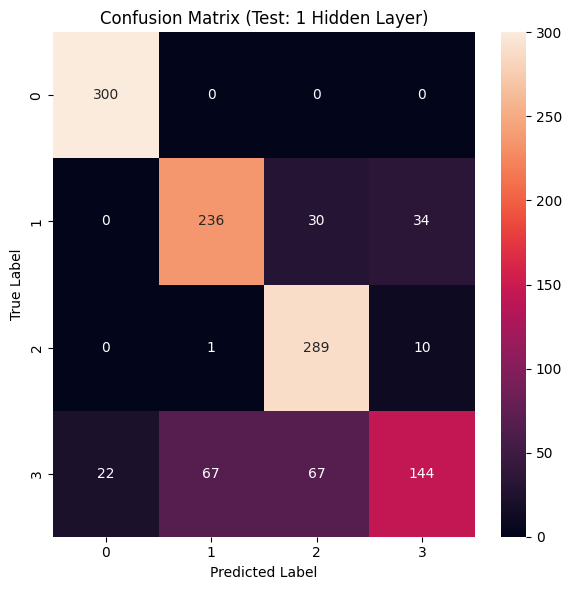

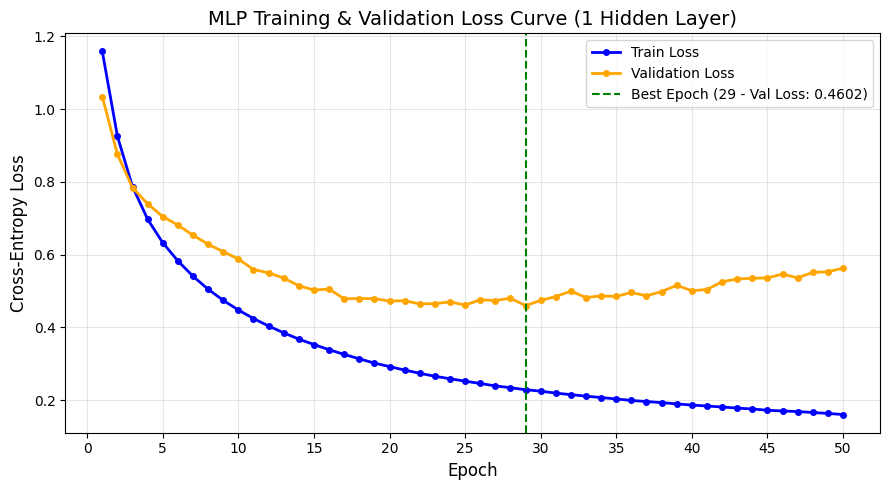

<Figure size 900x500 with 0 Axes>

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Plot Confusion Matrix Heatmap ---
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(6,6))
class_labels = list(range(cm.shape[0]))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix (Test: 1 Hidden Layer)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# --- Plot Standalone Loss Curve ---
train_epoch_ticks = list(range(1, len(train_losses) + 1))
epoch_ticks = list(range(1, len(val_losses) + 1))

plt.figure(figsize=(9, 5))

plt.plot(
    train_epoch_ticks,
    train_losses,
    label="Train Loss",
    color="blue",
    linewidth=2,
    marker="o",
    markersize=4,
)
plt.plot(
    epoch_ticks,
    val_losses,
    label="Validation Loss",
    color="orange",
    linewidth=2,
    marker="o",
    markersize=4,
)

# Vertical indicator using live variables from the loop
plt.axvline(
    x=best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch ({best_epoch} - Val Loss: {best_val_loss:.4f})",
)

plt.title("MLP Training & Validation Loss Curve (1 Hidden Layer)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)

# Adaptive ticks to handle early stopping cleanly
if len(epoch_ticks) <= 20:
    plt.xticks(epoch_ticks)
else:
    plt.xticks(range(0, len(epoch_ticks) + 1, 5))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

epoch_ticks = list(range(1, epochs + 1))
plt.figure(figsize=(9,5))
train_epoch_ticks = list(range(1, len(train_losses) + 1))
epoch_ticks = list(range(1, len(val_losses) + 1))



### 3 Hidden Layer MLP

In [64]:
# 3 Hidden Layer MLP Configuration [16 -> 256 -> 128 -> 64 -> 4]
class MLP_3Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(16, 256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(256, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.network(x)

In [65]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate model
model = MLP_3Layer()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

epochs = 50
best_val_loss = float("inf")
best_epoch = 0
best_model_weights = None
patience = 7
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
  print(f"Epoch {epoch}\n")

  # --- Training Phase ---
  model.train()
  running_train_loss = 0.0
  train_preds, train_targets = [], []

  for batch_idx, (X_b, y_b) in enumerate(train_loader):
    optimizer.zero_grad()
    outputs = model(X_b)
    loss = criterion(outputs, y_b)
    loss.backward()
    optimizer.step()

    running_train_loss += loss.item() * X_b.size(0)
    train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    train_targets.extend(y_b.cpu().numpy())

    if (batch_idx + 1) % 30 == 0 or (batch_idx + 1) == len(train_loader):
      pct = (batch_idx + 1) / len(train_loader) * 100
      print(f"loss: {loss.item():.6f}  [{pct:.1f}%]")

  epoch_train_loss = running_train_loss / len(train_loader.dataset)
  train_acc = accuracy_score(train_targets, train_preds)
  train_f1 = f1_score(train_targets, train_preds, average="macro")
  train_losses.append(epoch_train_loss)

  print(
      f"Train: Accuracy: {train_acc:.4f} | Macro F1 Score: {train_f1:.4f} |"
      f" Average Loss: {epoch_train_loss:.4f}"
  )

  # --- Validation Phase ---
  model.eval()
  running_val_loss = 0.0
  val_preds, val_targets = [], []

  with torch.no_grad():
    for X_b, y_b in val_loader:
      outputs = model(X_b)
      loss = criterion(outputs, y_b)
      running_val_loss += loss.item() * X_b.size(0)
      val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
      val_targets.extend(y_b.cpu().numpy())

  epoch_val_loss = running_val_loss / len(val_loader.dataset)
  val_acc = accuracy_score(val_targets, val_preds)
  val_f1 = f1_score(val_targets, val_preds, average="macro")
  val_losses.append(epoch_val_loss)

  print(
      f"Val: Accuracy: {val_acc:.4f} | Macro F1 Score: {val_f1:.4f} | Average"
      f" Loss: {epoch_val_loss:.4f}"
  )

  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    best_epoch = epoch
    best_model_weights = model.state_dict().copy()
    print("Best model weights saved based on validation loss.")

  print("-" * 32 + "\n")

# --- Test Evaluation ---
print("=== Evaluating Best Model on Test Set ===")
model.load_state_dict(best_model_weights)
model.eval()

test_preds, test_targets = [], []
running_test_loss = 0.0

with torch.no_grad():
  for X_b, y_b in test_loader:
    outputs = model(X_b)
    loss = criterion(outputs, y_b)
    running_test_loss += loss.item() * X_b.size(0)
    test_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    test_targets.extend(y_b.cpu().numpy())

test_loss = running_test_loss / len(test_loader.dataset)
test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average="macro")

print(
    f"Accuracy: {test_acc:.4f} | Macro F1 Score: {test_f1:.4f} | Average Loss:"
    f" {test_loss:.4f}"
)


Epoch 1

loss: 0.988391  [34.1%]
loss: 0.872459  [68.2%]
loss: 0.573860  [100.0%]
Train: Accuracy: 0.5604 | Macro F1 Score: 0.5396 | Average Loss: 0.8963
Val: Accuracy: 0.7008 | Macro F1 Score: 0.6762 | Average Loss: 0.7007
Best model weights saved based on validation loss.
--------------------------------

Epoch 2

loss: 0.595054  [34.1%]
loss: 0.433855  [68.2%]
loss: 0.586306  [100.0%]
Train: Accuracy: 0.7580 | Macro F1 Score: 0.7565 | Average Loss: 0.5202
Val: Accuracy: 0.7242 | Macro F1 Score: 0.7239 | Average Loss: 0.6347
Best model weights saved based on validation loss.
--------------------------------

Epoch 3

loss: 0.258658  [34.1%]
loss: 0.414280  [68.2%]
loss: 0.321828  [100.0%]
Train: Accuracy: 0.8395 | Macro F1 Score: 0.8396 | Average Loss: 0.3816
Val: Accuracy: 0.6908 | Macro F1 Score: 0.6794 | Average Loss: 0.7271
--------------------------------

Epoch 4

loss: 0.282201  [34.1%]
loss: 0.362505  [68.2%]
loss: 0.282539  [100.0%]
Train: Accuracy: 0.8838 | Macro F1 Score: 

## Confusion Matrix and Loss Curves

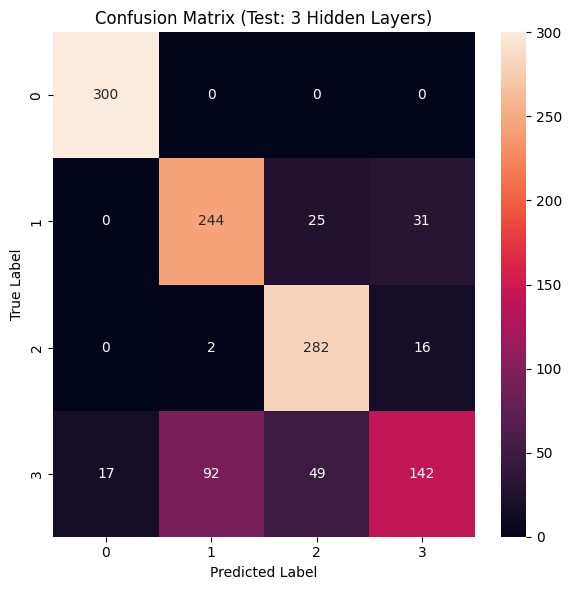

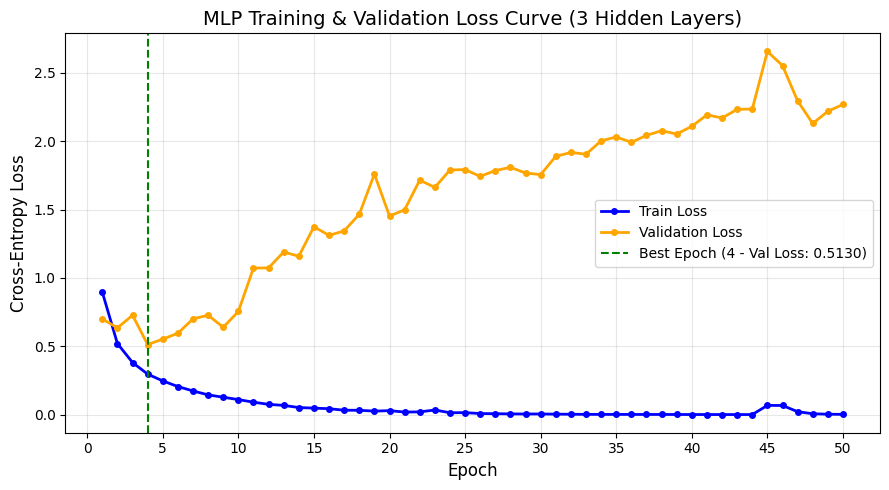

<Figure size 900x500 with 0 Axes>

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Plot Confusion Matrix Heatmap ---
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(6,6))
class_labels = list(range(cm.shape[0]))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix (Test: 3 Hidden Layers)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# --- Plot Standalone Loss Curve ---
train_epoch_ticks = list(range(1, len(train_losses) + 1))
epoch_ticks = list(range(1, len(val_losses) + 1))

plt.figure(figsize=(9, 5))

plt.plot(
    train_epoch_ticks,
    train_losses,
    label="Train Loss",
    color="blue",
    linewidth=2,
    marker="o",
    markersize=4,
)
plt.plot(
    epoch_ticks,
    val_losses,
    label="Validation Loss",
    color="orange",
    linewidth=2,
    marker="o",
    markersize=4,
)

# Vertical indicator using live variables from the loop
plt.axvline(
    x=best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch ({best_epoch} - Val Loss: {best_val_loss:.4f})",
)

plt.title("MLP Training & Validation Loss Curve (3 Hidden Layers)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)

# Adaptive ticks to handle early stopping cleanly
if len(epoch_ticks) <= 20:
    plt.xticks(epoch_ticks)
else:
    plt.xticks(range(0, len(epoch_ticks) + 1, 5))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

epoch_ticks = list(range(1, epochs + 1))
plt.figure(figsize=(9,5))
train_epoch_ticks = list(range(1, len(train_losses) + 1))
epoch_ticks = list(range(1, len(val_losses) + 1))



## Conclusion



The 1 hidden layer MLP architecture is the clear choice, offering the highest accuracy and stable perfomance without over-complicating the model. Adding more layers only caused the network to memorize the training data and make confident mistakes on new information. 